In [54]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [55]:
df = pd.read_csv('hospital_data.csv')
df.head(5)

,patient_id,age,gender,blood_pressure,cholesterol,bmi,diabetes,hypertension,medication_count,length_of_stay,discharge_destination,readmitted_30_days
0,1,74,Other,130/72,240,31.5,Yes,No,5,1,Nursing_Facility,Yes
1,2,46,Female,120/92,292,36.3,No,No,4,3,Nursing_Facility,No
2,3,89,Other,135/78,153,30.3,No,Yes,1,1,Home,No
3,4,84,Female,123/80,153,31.5,No,Yes,3,10,Home,No
4,5,32,Other,135/84,205,18.4,No,Yes,6,4,Nursing_Facility,No


In [56]:
print(df.shape)
print(df.isnull().sum())
print("info",df.info())
print("describe",df.describe())

(30000, 12)
patient_id               0
age                      0
gender                   0
blood_pressure           0
cholesterol              0
bmi                      0
diabetes                 0
hypertension             0
medication_count         0
length_of_stay           0
discharge_destination    0
readmitted_30_days       0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   patient_id             30000 non-null  int64  
 1   age                    30000 non-null  int64  
 2   gender                 30000 non-null  object 
 3   blood_pressure         30000 non-null  object 
 4   cholesterol            30000 non-null  int64  
 5   bmi                    30000 non-null  float64
 6   diabetes               30000 non-null  object 
 7   hypertension           30000 non-null  object 
 8   medication_count 

<Axes: >

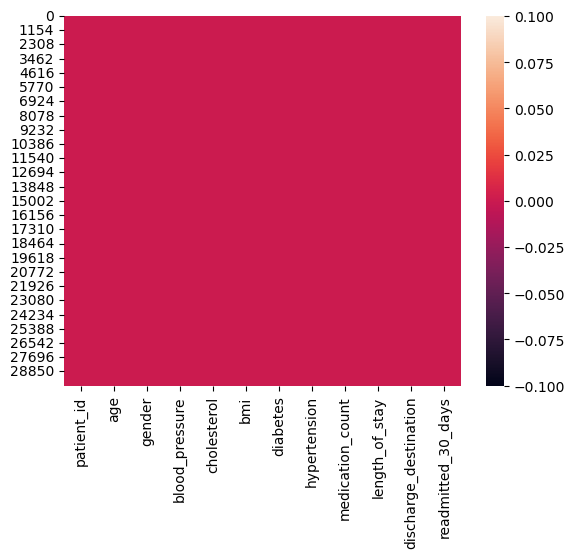

In [57]:
sns.heatmap(df.isnull())

In [58]:
df.columns

Index(['patient_id', 'age', 'gender', 'blood_pressure', 'cholesterol', 'bmi',
       'diabetes', 'hypertension', 'medication_count', 'length_of_stay',
       'discharge_destination', 'readmitted_30_days'],
      dtype='object')

In [59]:
print(df["readmitted_30_days"].value_counts()) # target distribution

readmitted_30_days
No     26326
Yes     3674
Name: count, dtype: int64


In [60]:
bp = df["blood_pressure"].str.split("/", expand=True).astype(float) # blood pressure ko distribute kra

df["systolic_bp"] = bp[0]
df["diastolic_bp"] = bp[1]

df.drop("blood_pressure", axis=1, inplace=True)

In [61]:
df.columns

Index(['patient_id', 'age', 'gender', 'cholesterol', 'bmi', 'diabetes',
       'hypertension', 'medication_count', 'length_of_stay',
       'discharge_destination', 'readmitted_30_days', 'systolic_bp',
       'diastolic_bp'],
      dtype='object')

In [62]:
df.drop("patient_id", axis=1,inplace=True, )

In [63]:
df["readmitted_30_days"] = df["readmitted_30_days"].map({ "Yes": 1, "No": 0}) # map target into 1/0

In [64]:
X = df.drop("readmitted_30_days", axis = 1)
y = df["readmitted_30_days"]

In [65]:
print(X.dtypes)

age                        int64
gender                    object
cholesterol                int64
bmi                      float64
diabetes                  object
hypertension              object
medication_count           int64
length_of_stay             int64
discharge_destination     object
systolic_bp              float64
diastolic_bp             float64
dtype: object


In [68]:
from sklearn.model_selection import train_test_split # train_test_split
X_train, X_test, y_train,y_test = train_test_split(X,y,test_size = 0.2, random_state = 42,stratify=y)

In [69]:
from sklearn.compose import ColumnTransformer  # Preprocessing 
from sklearn.preprocessing import StandardScaler, OneHotEncoder

categorical_features = [
    "gender",
    "diabetes",
    "hypertension",
    "discharge_destination"
]

numerical_features = [
    "age",
    "cholesterol",
    "bmi",
    "medication_count",
    "length_of_stay",
    "systolic_bp",
    "diastolic_bp"
]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),
    ("cat", OneHotEncoder(
        handle_unknown="ignore",
        drop="first"
    ), categorical_features)
])

In [72]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

model = Pipeline([("Preprocessing : ",preprocessor),("Logistic", LogisticRegression(
        penalty="l2", # L2 regularization.
        max_iter=1000,
        class_weight="balanced"
        ))])

In [74]:
model = model.fit(X_train, y_train)

In [76]:
y_pred = model.predict(X_test)
print(y_pred)

[0 1 0 ... 0 0 1]


In [80]:
y_prob = model.predict_proba(X_test)[:,1]
print(y_prob)

[0.4695386  0.57421628 0.44033771 ... 0.40828877 0.4412394  0.58760277]


In [81]:
# Probability >= 0.5 → Readmitted
# Probability < 0.5  → Not Readmitted

In [83]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,y_pred)
print(cm)

[[3723 1542]
 [ 439  296]]


In [84]:
#                  Predicted
#                  No      Yes

# Actual No       3723    1542
# Actual Yes       439     296

In [86]:
from sklearn.metrics import roc_auc_score
roc_auc= roc_auc_score(y_test,y_pred)
print(roc_auc) # Iska meaning? 
# Model ki discrimination ability weak hai. random model= 0.5 but slightly better h but not for clinic production deploy stage

0.5549217977789407


In [89]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("classification_report",classification_report(y_test,y_pred))

Accuracy: 0.6698333333333333
Precision: 0.16104461371055495
Recall: 0.40272108843537413
F1: 0.2300816167897396
classification_report               precision    recall  f1-score   support

           0       0.89      0.71      0.79      5265
           1       0.16      0.40      0.23       735

    accuracy                           0.67      6000
   macro avg       0.53      0.55      0.51      6000
weighted avg       0.80      0.67      0.72      6000

